Silhouette Score (StandardScaler): 0.2063
Silhouette Score (RobustScaler): 0.1817


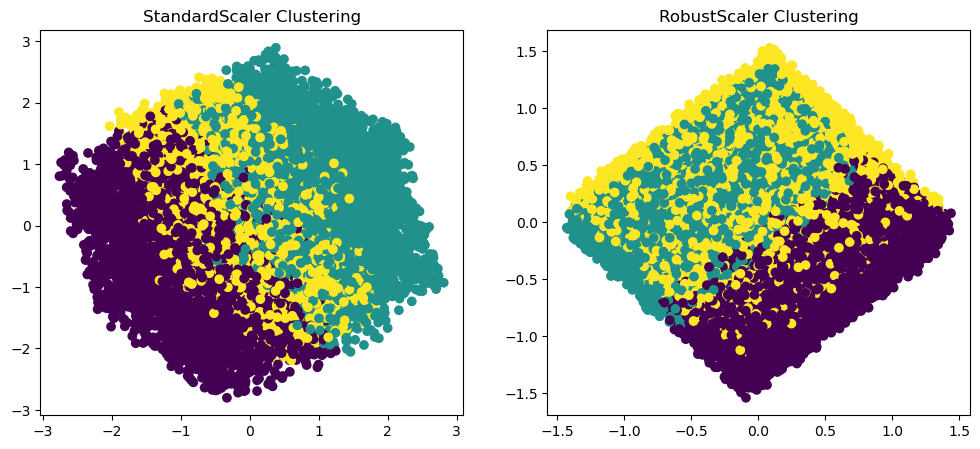

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# =========================
# 1. Load & prepare data
# =========================
df = pd.read_csv('data/data_preprocessed.csv')  # your saved file

X = df.copy()

# =========================
# 2. Apply StandardScaler
# =========================
standard_scaler = StandardScaler()
X_standard = standard_scaler.fit_transform(X)

# =========================
# 3. Apply RobustScaler
# =========================
robust_scaler = RobustScaler()
X_robust = robust_scaler.fit_transform(X)

# =========================
# 4. Clustering (K-Means)
# =========================
k = 3  # you can change this

kmeans_std = KMeans(n_clusters=k, random_state=42)
labels_std = kmeans_std.fit_predict(X_standard)

kmeans_rob = KMeans(n_clusters=k, random_state=42)
labels_rob = kmeans_rob.fit_predict(X_robust)

# =========================
# 5. Evaluate (Silhouette Score)
# =========================
score_std = silhouette_score(X_standard, labels_std)
score_rob = silhouette_score(X_robust, labels_rob)

print("Silhouette Score (StandardScaler):", round(score_std, 4))
print("Silhouette Score (RobustScaler):", round(score_rob, 4))

# =========================
# 6. PCA for visualization
# =========================
pca = PCA(n_components=2)

X_std_pca = pca.fit_transform(X_standard)
X_rob_pca = pca.fit_transform(X_robust)

# =========================
# 7. Plot comparison
# =========================
plt.figure(figsize=(12, 5))

# StandardScaler plot
plt.subplot(1, 2, 1)
plt.scatter(X_std_pca[:, 0], X_std_pca[:, 1], c=labels_std)
plt.title('StandardScaler Clustering')

# RobustScaler plot
plt.subplot(1, 2, 2)
plt.scatter(X_rob_pca[:, 0], X_rob_pca[:, 1], c=labels_rob)
plt.title('RobustScaler Clustering')

plt.show()